In [1]:
import os
import sys
import torch
import yaml
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)
from SimpleMAF import SimpleMAF
from Classifier_CW import Classifier_CW as Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
selection = "ML"


dataset_path = f"Final_Dataset_{selection}"
model_path = f"Models_Extrapolation_{selection}_ver2"
config_path = "configs" 
os.makedirs(model_path, exist_ok=True)


device = torch.device("cpu")
print(f"Using device: {device}")

features_to_generate = [
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj'
]

context_vars = [
    'met_recalc_pt', 'ht'
]

N_ENSEMBLES = 10

Using device: cpu


### Training

In [3]:
train_model = False

if train_model:
    USE_WEIGHTS = True

    print(f"\n{'='*70}")
    print(f" 🚀 PROCESSING: Generate in the {selection} Selection")
    print(f"{'='*70}")

    mc_train = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_train.parquet").to_pandas()
    data_train = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_train.parquet").to_pandas()

    print(f"MC Train -> {len(mc_train)}")
    print(f"Data Split -> Train: {len(data_train)}")

    x_mc_train_cw = mc_train[context_vars].values
    x_data_train_cw = data_train[context_vars].values

    y_mc_train_cw = np.zeros((x_mc_train_cw.shape[0], 1))
    y_data_train_cw = np.ones((x_data_train_cw.shape[0], 1))

    input_x_cw = np.vstack((x_data_train_cw, x_mc_train_cw))
    input_y_cw = np.vstack((y_data_train_cw, y_mc_train_cw))

    x_train = data_train[features_to_generate].values
    c_train = data_train[context_vars].values

    if USE_WEIGHTS:
        print("Using sample weights for training.")
        w_data = np.ones((x_data_train_cw.shape[0], 1))
        # Ensure 'final_weight' exists or fall back to 'raw_weights'
        weight_col = 'final_weight' 
        w_mc = mc_train[weight_col].values.reshape(-1, 1)
        input_w = np.vstack([w_data, w_mc])
    else:
        print("Training WITHOUT sample weights.")
        input_w = None


    with open(f"{config_path}/generate_physics.yml", 'r') as stream:
        params_gen = yaml.safe_load(stream)

    with open(f"{config_path}/context_weights_physics.yml", 'r') as stream:
        params_cw = yaml.safe_load(stream)

    for i in range(N_ENSEMBLES):
        print(f"\n--- Training Ensemble {i+1}/{N_ENSEMBLES} ---")

        NN_cw = Classifier(
            n_inputs=len(context_vars),
            layers=params_cw["layers"],
            learning_rate=params_cw["learning_rate"],
            device=device
        )


        MAF = SimpleMAF(
            num_features=len(features_to_generate), 
            num_context=len(context_vars), 
            num_hidden_features=params_gen["n_hidden_features"], 
            num_layers=params_gen["n_layers"], 
            learning_rate=float(params_gen["learning_rate"]),
            device=device
        )

        current_seed = 42 + i*7
        model_name = f"generate_ens{i}"
        model_name_cw = f"context_weights_ens{i}"

        NN_cw.train(
            input_x=input_x_cw,
            input_y=input_y_cw,
            weights=input_w,
            save_model=True,
            batch_size=params_cw["batch_size"],
            n_epochs=params_cw["n_epochs"],
            model_name=model_name_cw,
            outdir=model_path,
            early_stop=True,
            seed=current_seed
        )

        MAF.train(
            data=x_train, 
            cond=c_train, 
            batch_size=params_gen["batch_size"], 
            n_epochs=params_gen["n_epochs"], 
            outdir=model_path, 
            save_model=True, 
            model_name=model_name,
            seed=current_seed,
            early_stop=True
        )
print("\n🎉 Generative training phase complete!")


🎉 Generative training phase complete!


### Loss Evaluation

In [4]:
loss_path = os.path.join(model_path, "loss_data")
print(f"Loss data read from: {loss_path}")

Loss data read from: Models_Extrapolation_ML_ver2/loss_data


In [5]:
all_train_losses_gen = []
all_val_losses_gen = []

all_train_losses_cw = []
all_val_losses_cw = []

for i in range(N_ENSEMBLES):
    model_name = f"generate_ens{i}"
    model_name_cw = f"context_weights_ens{i}"
    loss_file = os.path.join(loss_path, f"{model_name}_loss.npz")
    loss_file_cw = os.path.join(loss_path, f"{model_name_cw}_loss.npz")

    if os.path.exists(loss_file):
        with np.load(loss_file) as loss_data:
            all_train_losses_gen.append(loss_data['train_loss'])
            all_val_losses_gen.append(loss_data['val_loss'])
        print(f"Loaded loss data for {model_name}")
    else:
        print(f"Warning: Loss file {loss_file} not found.")

    if os.path.exists(loss_file_cw):
        with np.load(loss_file_cw) as loss_data_cw:
            all_train_losses_cw.append(loss_data_cw['train_loss'])
            all_val_losses_cw.append(loss_data_cw['val_loss'])
        print(f"Loaded loss data for {model_name_cw}")
    else:
        print(f"Warning: Loss file {loss_file_cw} not found.")


# If no files were found, exit early
if not all_train_losses_gen and not all_train_losses_cw:
    raise FileNotFoundError("No loss files were found. Please check your path and model names.")


max_epochs_gen = max(len(loss) for loss in all_train_losses_gen)
max_epochs_cw = max(len(loss) for loss in all_train_losses_cw)

padded_train_losses_gen = []
padded_val_losses_gen = []
padded_train_losses_cw = []
padded_val_losses_cw = []

for train_loss, val_loss in zip(all_train_losses_gen, all_val_losses_gen):
    pad_length = max_epochs_gen - len(train_loss)

    # FORWARD FILLING (Recommended): Carries the final loss value forward
    padded_train_losses_gen.append(np.pad(train_loss, (0, pad_length), mode='edge'))
    padded_val_losses_gen.append(np.pad(val_loss, (0, pad_length), mode='edge'))
    
    # ALTERNATIVE (NaN Padding): If you prefer models to drop out of the average completely
    # padded_train_losses_gen.append(np.pad(train_loss, (0, pad_length), constant_values=np.nan))
    # padded_val_losses_gen.append(np.pad(val_loss, (0, pad_length), constant_values=np.nan))

for train_loss_cw, val_loss_cw in zip(all_train_losses_cw, all_val_losses_cw):
    pad_length_cw = max_epochs_cw - len(train_loss_cw)

    # FORWARD FILLING (Recommended): Carries the final loss value forward
    padded_train_losses_cw.append(np.pad(train_loss_cw, (0, pad_length_cw), mode='edge'))
    padded_val_losses_cw.append(np.pad(val_loss_cw, (0, pad_length_cw), mode='edge'))
    
    # ALTERNATIVE (NaN Padding): If you prefer models to drop out of the average completely
    # padded_train_losses_cw.append(np.pad(train_loss_cw, (0, pad_length_cw), constant_values=np.nan))
    # padded_val_losses_cw.append(np.pad(val_loss_cw, (0, pad_length_cw), constant_values=np.nan))

# Convert to 2D numpy arrays
all_train_losses_gen = np.array(padded_train_losses_gen)
all_val_losses_gen = np.array(padded_val_losses_gen)
all_train_losses_cw = np.array(padded_train_losses_cw)
all_val_losses_cw = np.array(padded_val_losses_cw)

Loaded loss data for generate_ens0
Loaded loss data for context_weights_ens0
Loaded loss data for generate_ens1
Loaded loss data for context_weights_ens1
Loaded loss data for generate_ens2
Loaded loss data for context_weights_ens2
Loaded loss data for generate_ens3
Loaded loss data for context_weights_ens3
Loaded loss data for generate_ens4
Loaded loss data for context_weights_ens4
Loaded loss data for generate_ens5
Loaded loss data for context_weights_ens5
Loaded loss data for generate_ens6
Loaded loss data for context_weights_ens6
Loaded loss data for generate_ens7
Loaded loss data for context_weights_ens7
Loaded loss data for generate_ens8
Loaded loss data for context_weights_ens8
Loaded loss data for generate_ens9
Loaded loss data for context_weights_ens9


In [6]:
# ==========================================
# 4. Calculate Statistics
# ==========================================
# Note: If you switch to the NaN padding alternative above, 
# you MUST change np.mean to np.nanmean and np.std to np.nanstd here.
mean_train_gen = np.mean(all_train_losses_gen, axis=0)
std_train_gen = np.std(all_train_losses_gen, axis=0)

mean_val_gen = np.mean(all_val_losses_gen, axis=0)
std_val_gen = np.std(all_val_losses_gen, axis=0)

# Create the master x-axis
epochs_array_gen = np.arange(max_epochs_gen)

mean_train_cw = np.mean(all_train_losses_cw, axis=0)
std_train_cw = np.std(all_train_losses_cw, axis=0)

mean_val_cw = np.mean(all_val_losses_cw, axis=0)
std_val_cw = np.std(all_val_losses_cw, axis=0)

epochs_array_cw = np.arange(max_epochs_cw)

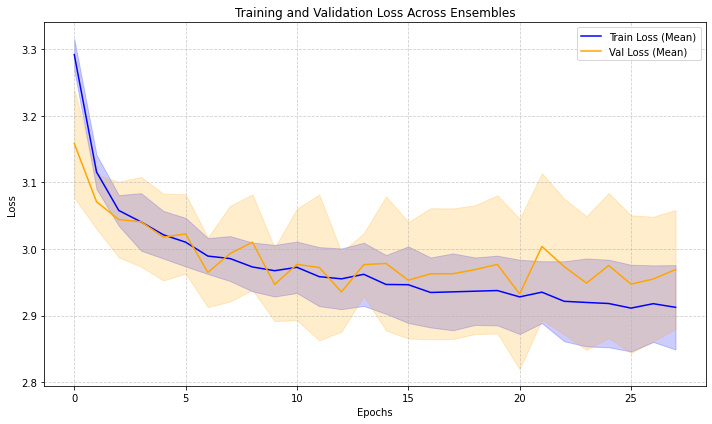

In [7]:
# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training Loss (Blue)
plt.plot(epochs_array_gen, mean_train_gen, color='blue', label='Train Loss (Mean)')
plt.fill_between(
    epochs_array_gen, 
    mean_train_gen - std_train_gen, 
    mean_train_gen + std_train_gen, 
    color='blue', 
    alpha=0.2
)

# Plot Validation Loss (Orange)
plt.plot(epochs_array_gen, mean_val_gen, color='orange', label='Val Loss (Mean)')
plt.fill_between(
    epochs_array_gen, 
    mean_val_gen - std_val_gen, 
    mean_val_gen + std_val_gen, 
    color='orange', 
    alpha=0.2
)

# Formatting
plt.title('Training and Validation Loss Across Ensembles')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

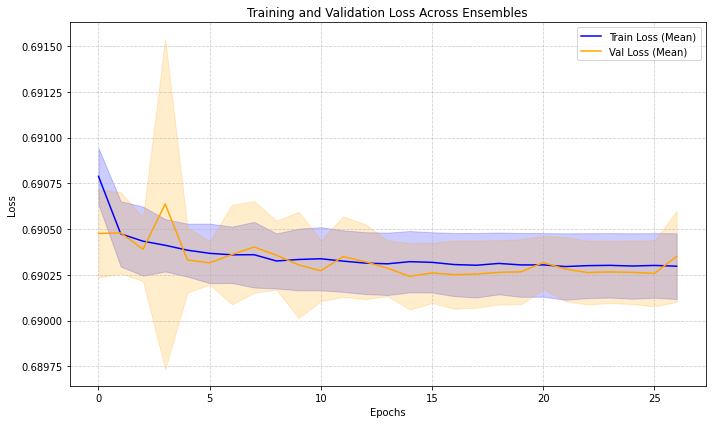

In [8]:
# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training Loss (Blue)
plt.plot(epochs_array_cw, mean_train_cw, color='blue', label='Train Loss (Mean)')
plt.fill_between(
    epochs_array_cw, 
    mean_train_cw - std_train_cw, 
    mean_train_cw + std_train_cw, 
    color='blue', 
    alpha=0.2
)

# Plot Validation Loss (Orange)
plt.plot(epochs_array_cw, mean_val_cw, color='orange', label='Val Loss (Mean)')
plt.fill_between(
    epochs_array_cw, 
    mean_val_cw - std_val_cw, 
    mean_val_cw + std_val_cw, 
    color='orange', 
    alpha=0.2
)

# Formatting
plt.title('Training and Validation Loss Across Ensembles')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Quick Check

#### CR

In [9]:
# 1. Load Data
data_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_test.parquet").to_pandas()
mc_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_test.parquet").to_pandas()

print(f"Data Split -> Test: {len(data_test)}")
print(f"MC Split   -> Test: {len(mc_test)}")

Data Split -> Test: 960854
MC Split   -> Test: 635642


In [10]:
pred_cond = mc_test[context_vars].values

# Extract the base nominal MC weights
mc_base_weight_col = "final_weight"
mc_base_weights = mc_test[mc_base_weight_col].to_numpy() if mc_base_weight_col else np.ones(len(mc_test))

In [11]:
def generate_samples(model, pred_cond, over_sample):

    return model.sample(over_sample, pred_cond)
# Store the generated output for each ensemble
ensemble_results = []

for i in range(N_ENSEMBLES):
    model_name_gen = f"generate_ens{i}"
    model_file_gen = os.path.join(model_path, f"{model_name_gen}.pt")
    
    model_name_cw = f"context_weights_ens{i}"
    model_file_cw = os.path.join(model_path, f"{model_name_cw}.pt")
    
    if os.path.exists(model_file_gen) and os.path.exists(model_file_cw):
        print(f"\nProcessing ensemble {i}...")

        # --- Generate Samples ---
        model_gen = torch.load(model_file_gen, map_location=device, weights_only=False)
        model_gen.to(device)
        generated_samples = generate_samples(model_gen, pred_cond, over_sample=1)
        
        # --- Generate Context Weights ---
        model_cw = torch.load(model_file_cw, map_location=device, weights_only=False)
        model_cw.to(device)
        cw_prob = model_cw.evaluation(pred_cond)
        cw = (cw_prob / (1 - cw_prob)).flatten()

        # --- Build Ensemble DataFrame ---
        # 1. Add Generated Feature Variables
        df_ens = pd.DataFrame(generated_samples, columns=features_to_generate)
        
        # 2. Add Original MC Context Variables
        for c_var in context_vars:
            df_ens[c_var] = mc_test[c_var].values
            
        # 3. Add the Combined Weights (final_weight * cw)
        df_ens['total_weight'] = mc_base_weights * cw
        df_ens['final_weight'] = mc_base_weights  # Store the original MC weights for reference
        
        ensemble_results.append(df_ens)

        df_ens.to_parquet(f"{model_path}/samples/MC_CR_Generate_ens{i}.parquet", index=False)
        print(df_ens.columns)
        
        print(f"  -> Generated samples shape: {generated_samples.shape}")
        print(f"  -> Context weights shape: {cw.shape}")
    else:
        print(f"Warning: Models for ensemble {i} not fully found. Skipping.")


Processing ensemble 0...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (635642, 5)
  -> Context weights shape: (635642,)

Processing ensemble 1...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (635642, 5)
  -> Context weights shape: (635642,)

Processing ensemble 2...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (635642, 5)
  -> Context weights shape: (635642,)

Processing ensemble 3...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated sampl

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import gridspec, ticker
from scipy.stats import chi2 as chi2_stat
from scipy.stats import wasserstein_distance

def plot_closure_generative(region_name: str, df_mc: pd.DataFrame, df_data: pd.DataFrame, ensemble_results: list, feature: str, features_to_generate: list, force_log: bool = False, custom_bins = None):
    
    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5 
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    # Extract Target Data & Nominal MC Arrays
    data_arr = df_data[feature].dropna().to_numpy()
    mc_arr = df_mc[feature].dropna().to_numpy()
    
    if len(data_arr) == 0 or len(mc_arr) == 0:
        print(f"Skipping {feature} - Missing data or MC.")
        return
        
    # Extract Data Weights
    data_weights = np.ones_like(data_arr)
    
    # Extract Nominal MC Weights
    mc_weight_col = "final_weight"
    raw_weights_mc = df_mc[mc_weight_col].to_numpy() if mc_weight_col else np.ones_like(mc_arr)
    
    # Setup Figure Layout
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Define Binning & Clip Arrays (if custom)
    if custom_bins is not None:
        bins = custom_bins
        data_arr = np.clip(data_arr, bins[0], bins[-1])
        mc_arr = np.clip(mc_arr, bins[0], bins[-1])
    else:
        combined_arr = np.concatenate([data_arr, mc_arr, ensemble_results[0][feature].to_numpy()])
        bins = np.histogram_bin_edges(combined_arr, bins=15)
        
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # ==========================================
    # 1. MAIN PANEL CALCULATIONS & PLOTTING
    # ==========================================
    
    # --- Target Data ---
    counts_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights)
    sumw2_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights**2)
    data_errors = np.sqrt(sumw2_data)
    
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
                     fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)
                     
    # --- Nominal MC (Red Step Line) ---
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc)
    sumw2_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc**2)
    mc_err_raw = np.sqrt(sumw2_mc_raw)
    
    ax_main.hist(bins[:-1], bins=bins, weights=counts_mc_raw, histtype='step', 
                 color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                 
    ax_main.bar(bin_centers, 2 * mc_err_raw, bottom=counts_mc_raw - mc_err_raw, width=bin_widths,
                color='none', edgecolor='gray', hatch='////', linewidth=0,
                alpha=0.5, zorder=5, label='Nom Stat Unc.')
    
    # --- Prediction (Blue Filled) ---
    ens_yields = []
    ens_sumw2 = []
    
    for df_ens in ensemble_results:
        pred_arr = df_ens[feature].to_numpy()
        if custom_bins is not None:
            pred_arr = np.clip(pred_arr, bins[0], bins[-1])
            
        # pred_weights = df_ens['total_weight'].to_numpy()
        pred_weights = df_ens['final_weight'].to_numpy()
        # pred_weights = np.ones_like(pred_arr)  # Default to uniform weights if 'total_weight' is not available
        
        y, _ = np.histogram(pred_arr, bins=bins, weights=pred_weights)
        y_sumw2, _ = np.histogram(pred_arr, bins=bins, weights=pred_weights**2)
        
        ens_yields.append(y)
        ens_sumw2.append(y_sumw2)
        
    ens_yields = np.array(ens_yields)
    ens_sumw2 = np.array(ens_sumw2)
    
    counts_pred = np.mean(ens_yields, axis=0)
    mean_stat_var = np.mean(ens_sumw2, axis=0)
    ensemble_variance = np.var(ens_yields, axis=0, ddof=1) if len(ensemble_results) > 1 else np.zeros_like(counts_pred)
    total_var_pred = mean_stat_var + ensemble_variance
    total_err_pred = np.sqrt(total_var_pred)
    
    label_str = 'Generative Model' if feature in features_to_generate else 'Reweighted Context'
    
    ax_main.hist(bins[:-1], bins=bins, weights=counts_pred, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label=label_str)
                 
    ax_main.bar(bin_centers, 2 * total_err_pred, bottom=counts_pred - total_err_pred, width=bin_widths,
                color='none', edgecolor='#1f78b4', hatch='\\\\\\\\', linewidth=0,
                alpha=0.3, zorder=6, label='Pred Tot Unc.')

    # ==========================================
    # METRICS CALCULATION
    # ==========================================
    std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    c_data_clean = np.clip(counts_data, 0, None)
    
    w1_nom  = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_raw, 0, None)) / std_data
    w1_pred = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_pred, 0, None)) / std_data

    def get_chi2_pval(c_target, c_pred, s2_target, s2_pred):
        mask = (c_target > 0) | (c_pred > 0)
        tot_var = s2_target[mask] + s2_pred[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_target[mask][valid] - c_pred[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        p_val = chi2_stat.sf(chi2_val, ndf)
        return chi2_val, ndf, p_val

    chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_data, sumw2_mc_raw)
    chi2_pred, ndf_pred, p_pred = get_chi2_pval(counts_data, counts_pred, sumw2_data, total_var_pred)

    print(f"Metrics for {feature} in {region_name}:")
    print(f"  Nominal MC -> chi2/ndf: {chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | Norm W1: {w1_nom:.4f}")
    print(f"  Prediction -> chi2/ndf: {chi2_pred:.2f}/{ndf_pred} (p={p_pred:.4f}) | Norm W1: {w1_pred:.4f}")
    print("-" * 70)

    # --- MAIN PANEL FORMATTING ---
    max_counts = max(
        np.max(counts_data) + np.max(data_errors) if len(counts_data) > 0 else 0,
        np.max(counts_mc_raw + mc_err_raw) if len(counts_mc_raw) > 0 else 0,
        np.max(counts_pred + total_err_pred) if len(counts_pred) > 0 else 0,
    )
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, max_counts * 1000)
    else:
        ax_main.set_ylim(0, max_counts * 1.55)
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = f"{region_name} selection\nClosure Test\n" + r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    # Reorder legends to put Target Data first
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Target Data" in loc_labels:
        idx = loc_labels.index("Target Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)
    
    # ==========================================
    # 2. RATIO PANEL
    # ==========================================
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_raw = counts_data / counts_mc_raw
        ratio_pred = counts_data / counts_pred
        
        ratio_raw_data_err  = np.where(counts_mc_raw > 0, data_errors / counts_mc_raw, 0)
        ratio_pred_data_err = np.where(counts_pred > 0, data_errors / counts_pred, 0)
        
        rel_err_raw   = np.where(counts_mc_raw > 0, mc_err_raw / counts_mc_raw, 0)
        rel_err_pred  = np.where(counts_pred > 0, total_err_pred / counts_pred, 0) 
        
        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_pred = np.where(counts_pred > 0, ratio_pred, np.nan)

    ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1.0, zorder=1)

    # Plot Nominal Uncertainty Band
    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths,
                 color='none', edgecolor='#e31a1c', hatch='////', linewidth=0, 
                 alpha=0.4, zorder=2, label='Nom Stat')

    # Plot Prediction Uncertainty Band
    ax_ratio.bar(bin_centers, 2 * rel_err_pred, bottom=1.0 - rel_err_pred, width=bin_widths,
                 color='#1f78b4', edgecolor='none', 
                 alpha=0.25, zorder=3, label='Pred Tot')
                 
    # Plot Nominal Ratio (Red Open Circles)
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_data_err, fmt='o', 
                      color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, 
                      capsize=0, markersize=6, zorder=10)
    
    # Plot Prediction Ratio (Blue Filled Circles)
    ax_ratio.errorbar(bin_centers, ratio_pred, yerr=ratio_pred_data_err, fmt='o', 
                      color='#1f78b4', capsize=0, markersize=5, zorder=11)

    # --- RATIO PANEL FORMATTING ---
    x_label = pretty_labels.get(feature, feature)
    ax_ratio.set_xlabel(x_label)
    ax_ratio.set_ylabel("Data / Pred")
    
    ax_ratio.set_ylim(0.5, 1.5) 
    ax_ratio.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
    
    fig.align_ylabels((ax_main, ax_ratio))

    plt.show()
    plt.close(fig)


Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in CR:
  Nominal MC -> chi2/ndf: 3389.69/6 (p=0.0000) | Norm W1: 0.1395
  Prediction -> chi2/ndf: 3389.69/6 (p=0.0000) | Norm W1: 0.1395
----------------------------------------------------------------------


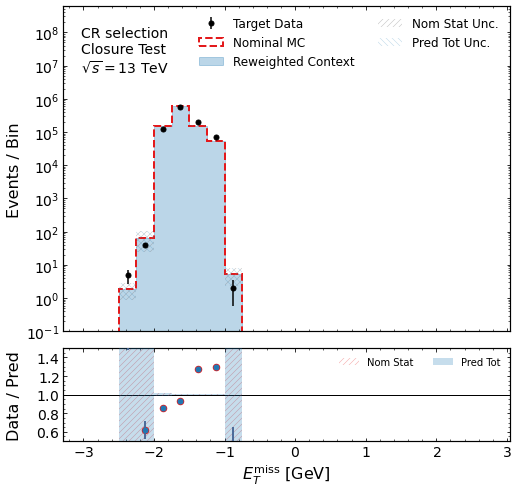


Generating closure plot for feature: ht
Metrics for ht in CR:
  Nominal MC -> chi2/ndf: 1353.86/13 (p=0.0000) | Norm W1: 0.0417
  Prediction -> chi2/ndf: 1353.86/13 (p=0.0000) | Norm W1: 0.0417
----------------------------------------------------------------------


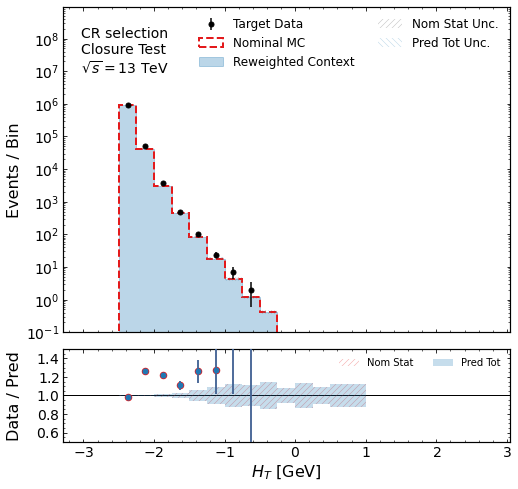


Generating closure plot for feature: mjj
Metrics for mjj in CR:
  Nominal MC -> chi2/ndf: 224.68/14 (p=0.0000) | Norm W1: 0.0502
  Prediction -> chi2/ndf: 38.38/22 (p=0.0166) | Norm W1: 0.0502
----------------------------------------------------------------------


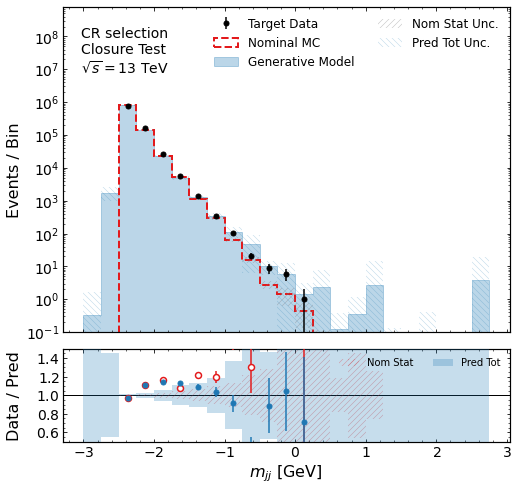


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in CR:
  Nominal MC -> chi2/ndf: 466.19/19 (p=0.0000) | Norm W1: 0.0853
  Prediction -> chi2/ndf: 35.99/22 (p=0.0304) | Norm W1: 0.0295
----------------------------------------------------------------------


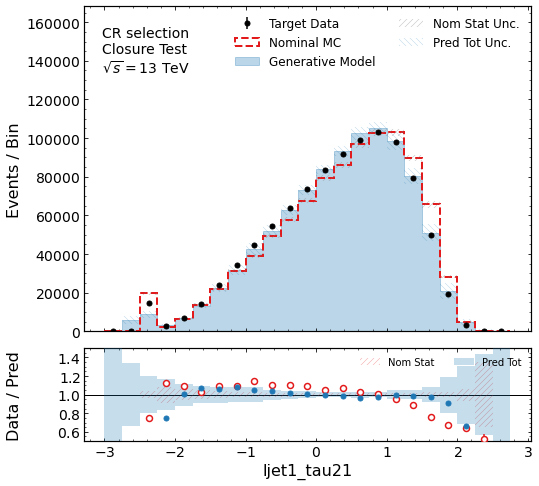


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in CR:
  Nominal MC -> chi2/ndf: 651.29/19 (p=0.0000) | Norm W1: 0.0801
  Prediction -> chi2/ndf: 21.14/22 (p=0.5119) | Norm W1: 0.0183
----------------------------------------------------------------------


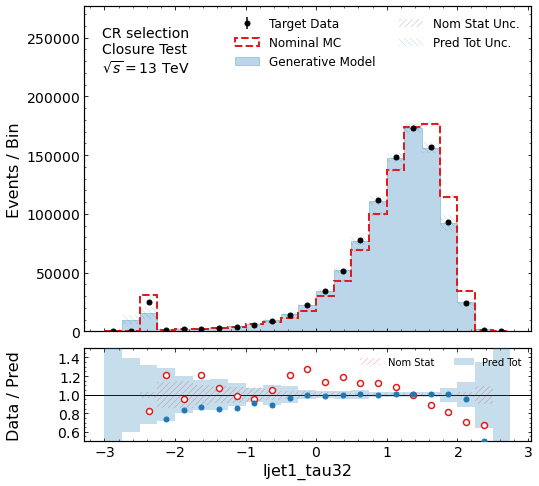


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in CR:
  Nominal MC -> chi2/ndf: 712.69/19 (p=0.0000) | Norm W1: 0.1211
  Prediction -> chi2/ndf: 13.52/22 (p=0.9177) | Norm W1: 0.0146
----------------------------------------------------------------------


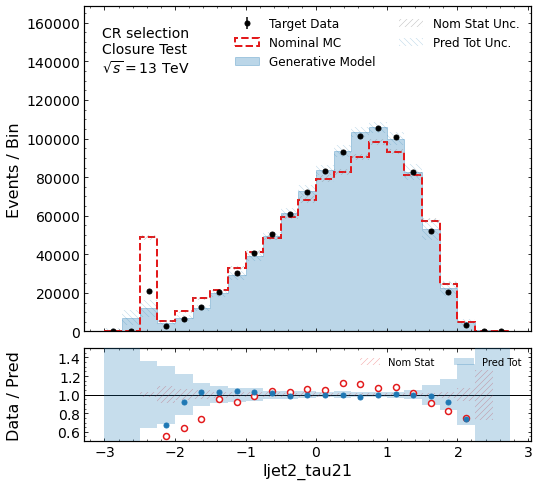


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in CR:
  Nominal MC -> chi2/ndf: 1137.42/19 (p=0.0000) | Norm W1: 0.2167
  Prediction -> chi2/ndf: 16.97/22 (p=0.7651) | Norm W1: 0.0239
----------------------------------------------------------------------


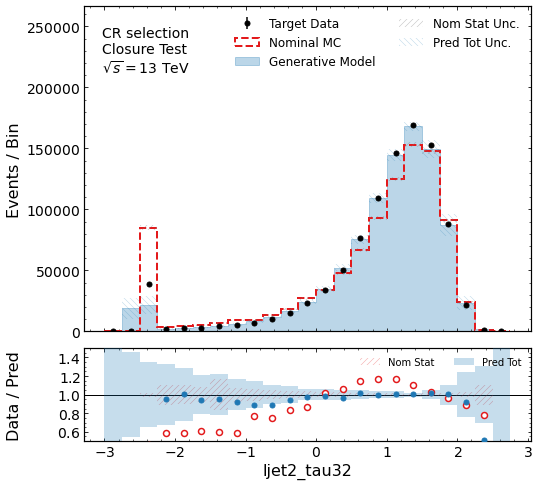

In [13]:
# Assuming you generated ensemble_results in the loop from the previous step
fixed_bins = np.arange(-3.0, 3.0, 0.25)
all_features_to_plot = context_vars +  [ 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']


for feature in all_features_to_plot:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure_generative("CR", mc_test, data_test, ensemble_results, feature, features_to_generate, custom_bins=fixed_bins)


### Signal Region

In [14]:
mc_sr = pl.read_parquet(f"{dataset_path}/MC_SR_clean.parquet").to_pandas()
data_sr = pl.read_parquet(f"{dataset_path}/DATA_SR_clean.parquet").to_pandas()
print(f"SR MC Split   -> Test: {len(mc_sr)}")
print(f"SR Data Split -> Test: {len(data_sr)}")

SR MC Split   -> Test: 528846
SR Data Split -> Test: 188757


In [15]:
pred_cond_sr = mc_sr[context_vars].values

# Extract the base nominal MC weights
mc_base_weight_col = "final_weight"
mc_base_weights = mc_sr[mc_base_weight_col].to_numpy() if mc_base_weight_col else np.ones(len(mc_sr))

In [16]:


ensemble_results_sr = []

for i in range(N_ENSEMBLES):
    model_name_gen = f"generate_ens{i}"
    model_file_gen = os.path.join(model_path, f"{model_name_gen}.pt")
    
    model_name_cw = f"context_weights_ens{i}"
    model_file_cw = os.path.join(model_path, f"{model_name_cw}.pt")
    
    if os.path.exists(model_file_gen) and os.path.exists(model_file_cw):
        print(f"\nProcessing ensemble {i}...")

        # --- Generate Samples ---
        model_gen = torch.load(model_file_gen, map_location=device, weights_only=False)
        model_gen.to(device)
        generated_samples = generate_samples(model_gen, pred_cond_sr, over_sample=1)
        
        # --- Generate Context Weights ---
        model_cw = torch.load(model_file_cw, map_location=device, weights_only=False)
        model_cw.to(device)
        cw_prob = model_cw.evaluation(pred_cond_sr)
        cw = (cw_prob / (1 - cw_prob)).flatten()

        # --- Build Ensemble DataFrame ---
        # 1. Add Generated Feature Variables
        df_ens = pd.DataFrame(generated_samples, columns=features_to_generate)
        
        # 2. Add Original MC Context Variables
        for c_var in context_vars:
            df_ens[c_var] = mc_sr[c_var].values
            
        # 3. Add the Combined Weights (final_weight * cw)
        df_ens['total_weight'] = mc_base_weights * cw
        df_ens['final_weight'] = mc_base_weights  # Store the original MC weights for reference
        
        df_ens.to_parquet(f"{model_path}/samples/MC_SR_Generate_ens{i}.parquet", index=False)
        print(df_ens.columns)

        ensemble_results_sr.append(df_ens)
        
        print(f"  -> Generated samples shape: {generated_samples.shape}")
        print(f"  -> Context weights shape: {cw.shape}")
    else:
        print(f"Warning: Models for ensemble {i} not fully found. Skipping.")


Processing ensemble 0...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (528846, 5)
  -> Context weights shape: (528846,)

Processing ensemble 1...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (528846, 5)
  -> Context weights shape: (528846,)

Processing ensemble 2...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated samples shape: (528846, 5)
  -> Context weights shape: (528846,)

Processing ensemble 3...
Index(['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj',
       'met_recalc_pt', 'ht', 'total_weight', 'final_weight'],
      dtype='object')
  -> Generated sampl


Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in SR:
  Nominal MC -> chi2/ndf: 47.23/14 (p=0.0000) | Norm W1: 0.0043
  Prediction -> chi2/ndf: 47.23/14 (p=0.0000) | Norm W1: 0.0043
----------------------------------------------------------------------


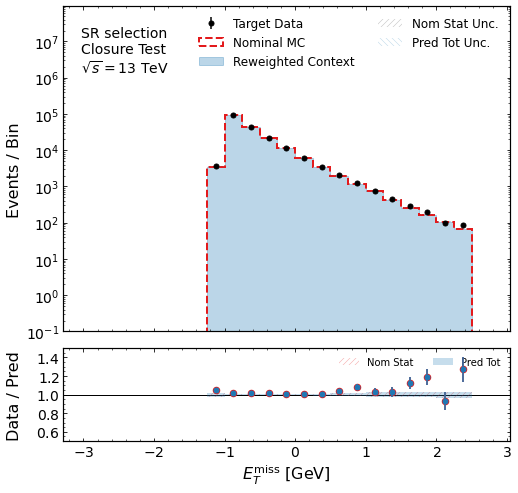


Generating closure plot for feature: ht
Metrics for ht in SR:
  Nominal MC -> chi2/ndf: 38.06/5 (p=0.0000) | Norm W1: 0.0083
  Prediction -> chi2/ndf: 38.06/5 (p=0.0000) | Norm W1: 0.0083
----------------------------------------------------------------------


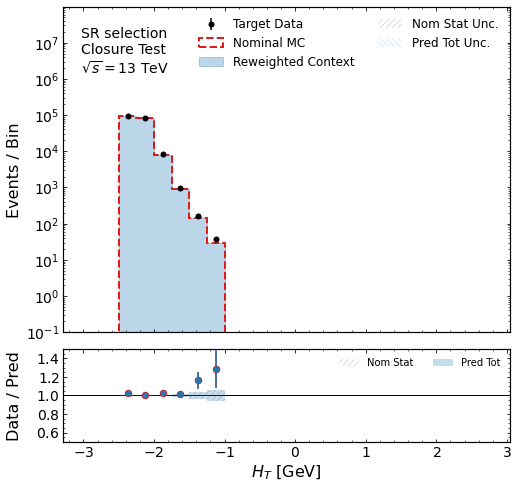


Generating closure plot for feature: mjj
Metrics for mjj in SR:
  Nominal MC -> chi2/ndf: 391.35/12 (p=0.0000) | Norm W1: 0.0635
  Prediction -> chi2/ndf: 12.52/22 (p=0.9457) | Norm W1: 0.0259
----------------------------------------------------------------------


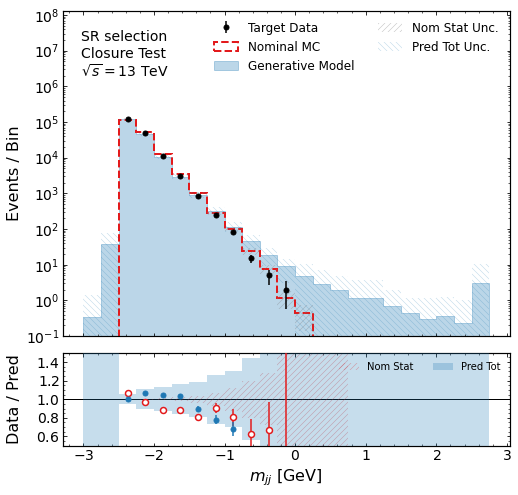


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in SR:
  Nominal MC -> chi2/ndf: 791.97/20 (p=0.0000) | Norm W1: 0.0555
  Prediction -> chi2/ndf: 48.89/22 (p=0.0008) | Norm W1: 0.0959
----------------------------------------------------------------------


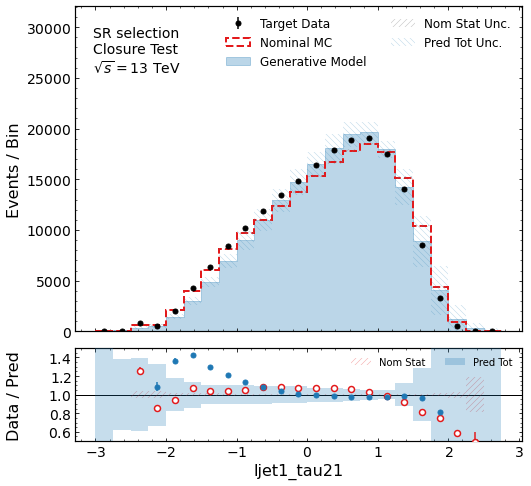


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in SR:
  Nominal MC -> chi2/ndf: 1623.85/19 (p=0.0000) | Norm W1: 0.0904
  Prediction -> chi2/ndf: 15.18/22 (p=0.8546) | Norm W1: 0.0691
----------------------------------------------------------------------


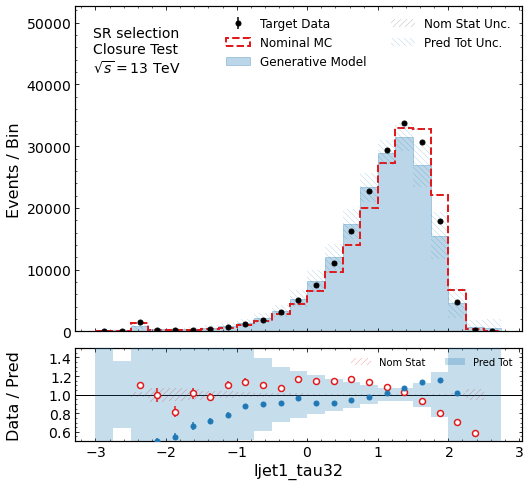


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in SR:
  Nominal MC -> chi2/ndf: 878.83/19 (p=0.0000) | Norm W1: 0.0559
  Prediction -> chi2/ndf: 9.19/22 (p=0.9923) | Norm W1: 0.0520
----------------------------------------------------------------------


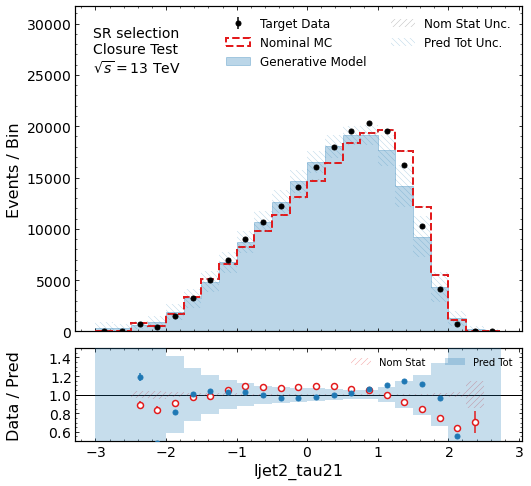


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in SR:
  Nominal MC -> chi2/ndf: 1386.33/19 (p=0.0000) | Norm W1: 0.0765
  Prediction -> chi2/ndf: 19.57/22 (p=0.6099) | Norm W1: 0.0349
----------------------------------------------------------------------


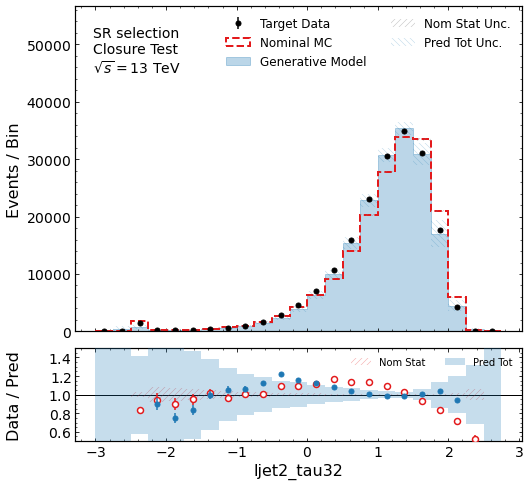

In [17]:
# Assuming you generated ensemble_results in the loop from the previous step

for feature in all_features_to_plot:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure_generative("SR", mc_sr, data_sr, ensemble_results_sr, feature, features_to_generate, custom_bins=fixed_bins)
